In [1]:
import numpy as np
import xrft
import matplotlib.pyplot as plt
from pathlib import Path
import os
import xarray as xr

from dask.distributed import Client
client = Client()
client

basepath = Path("/home/149/ab8992/topographic-NIWs/rundirs/common/default")


In [ ]:
basepath = "/g/data/nm03/ab8992/bottom-niws/height_1000/"
u_zon = xr.open_mfdataset(f"{basepath}/zonal/u_*.nc",decode_times = False,chunks = {"xq":-1}).u.mean("yh").isel(time = slice(0,200))
v_zon = xr.open_mfdataset(f"{basepath}/zonal/v_*.nc",decode_times = False,chunks = {"yq":-1}).v.mean("yq").isel(time = slice(0,200))
u_merid = xr.open_mfdataset(f"{basepath}/merid/u_*.nc",decode_times = False,chunks = {"xq":-1}).u.mean("xq").isel(time = slice(0,200))
v_merid = xr.open_mfdataset(f"{basepath}/merid/v_*.nc",decode_times = False,chunks = {"yq":-1}).v.mean("xh").isel(time = slice(0,200))
u_zon = u_zon - u_zon.isel(xq = 0)
v_zon = v_zon - v_zon.isel(xh = 0)
v_zon = v_zon.interp(xh = u_zon.xq).drop("xh").fillna(0)
u_merid = u_merid.interp(yh = v_merid.yq).drop("yh").fillna(0)

u_zon = u_zon.sel(xq = slice(None,None))
v_zon = v_zon.sel(xq = slice(None,None))
u_merid = u_merid.sel(yq = slice(None,None))
v_merid = v_merid.sel(yq = slice(None,None))

def flip(u,dim):
    u_flipped = xr.DataArray(
        data = u[::-1,:,:],
        coords = [1200 - u.time[::-1],u.zl,u[dim]],
        dims = ["time","zl",dim]
    )

    u_doubled = xr.concat([u_flipped,u],dim = "time")
    return u_doubled

u_zon = flip(u_zon,"xq")
v_zon = flip(v_zon,"xq")
u_merid = flip(u_merid,"yq")
v_merid = flip(v_merid,"yq")


KeyboardInterrupt: 

## Read in the new experiment instead
I've re-run the default experiment. All raw outputs available 

In [2]:
basepath = Path("/home/149/ab8992/topographic-NIWs/rundirs/common/default")

xr.open_mfdataset(str(
    basepath / "archive" / "output*" / "u.nc"),decode_times = False,decode_cf = False
).sel(yh = slice(-5,5)).u.chunk({"zl":1}).yh.values

array([-5., -3., -1.,  1.,  3.,  5.])

## Figure out a good integer number multiple of inertial periods to average over

In [3]:
f = 0.0001 / (np.pi * 2)
T_hours = (np.pi * 2 / 0.0001) / 3600

for i in range(50):
        if (np.abs(((3 * i * T_hours) % 1) - 1)) < 0.2:
            print(i,(np.abs(((3 * i * T_hours) % 1) - 1)))

8 0.12097952136093681
11 0.041346841871359175
19 0.162326363232296
22 0.08269368374271835
25 0.0030610042529133352
33 0.12404052561396384
36 0.0444078461243862
44 0.1653873674854367
47 0.08575468799563168


In [69]:
17.45 * 10

174.5

In [4]:
basepath = Path("/home/149/ab8992/topographic-NIWs/rundirs/common/default")
tmax = 17.45 * 10 * 3600 # 6 outputs per hour * 17 hour inertial periods * 5 inertial periods


tmin = 17.45 * 3600 # start after  1 inertial period
u_zon = xr.open_mfdataset(str(
    basepath / "archive" / "output*" / "u.nc"),decode_times = False,decode_cf = False
).sel(yh = 150,method = "nearest").sel(time = slice(0,tmax)).u.load().chunk({"zl":1})
# v_zon = xr.open_mfdataset(str(
#     basepath / "archive" / "output*" / "v.nc"),decode_times = False,decode_cf = False
# ).sel(yq = 150,method = "nearest").sel(time = slice(0,tmax)).v.load().chunk({"zl":1})
# u_merid = xr.open_mfdataset(str(
#     basepath / "archive" / "output*" / "u.nc"),decode_times = False,decode_cf = False
# ).sel(xq = slice(0,5)).u.mean("xq").sel(time = slice(0,tmax)).load().chunk({"zl":1})
v_merid = xr.open_mfdataset(str(
    basepath / "archive" / "output*" / "v.nc"),decode_times = False,decode_cf = False
).sel(xh = slice(0,5)).v.mean("xh").sel(time = slice(0,tmax)).load().chunk({"zl":1})

# u_zon = u_zon - u_zon.mean("xq")
# v_zon = v_zon - v_zon.mean("xh")

u_zon = u_zon - u_zon.isel(xq = 0)
# v_zon = v_zon - v_zon.isel(xh = 0)

# v_zon = v_zon.interp(xh = u_zon.xq).drop("xh").fillna(0)
# u_merid = u_merid.interp(yh = v_merid.yq).drop("yh").fillna(0)

u_zon = u_zon.where(u_zon.time > tmin,0)
# v_zon = v_zon.where(u_zon.time > tmin,0)
# u_merid = u_merid.where(u_zon.time > tmin,0)
v_merid = v_merid.where(u_zon.time > tmin,0)

def flip(u,dim):
    u_flipped = xr.DataArray(
        data = u[::-1,:,:],
        coords = [1200 - u.time[::-1],u.zl,u[dim]],
        dims = ["time","zl",dim]
    )

    u_doubled = xr.concat([u_flipped,u],dim = "time")
    return u_doubled

u_zon = flip(u_zon,"xq")
# v_zon = flip(v_zon,"xq")
# u_merid = flip(u_merid,"yq")
v_merid = flip(v_merid,"yq")

/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/distributed/client.py:3357: UserWarning: Sending large graph of size 11.91 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(


In [38]:
# u_zon.to_netcdf(basepath / "archive" / "u_zon.nc")
# v_zon.to_netcdf(basepath / "archive" / "v_zon.nc")
# u_merid.to_netcdf(basepath / "archive" / "u_merid.nc")
# v_merid.to_netcdf(basepath / "archive" / "v_merid.nc")

u_zon = xr.open_dataset(str(basepath / "archive" / "u_zon.nc")).sel(time = slice(-300000,300000)).u
v_zon = xr.open_dataset(str(basepath / "archive" / "v_zon.nc")).sel(time = slice(-300000,300000)).v
u_merid = xr.open_dataset(str(basepath / "archive" / "u_merid.nc")).sel(time = slice(-300000,300000)).u
v_merid = xr.open_dataset(str(basepath / "archive" / "v_merid.nc")).sel(time = slice(-300000,300000)).v





/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/distributed/client.py:3357: UserWarning: Sending large graph of size 15.62 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(
/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/distributed/client.py:3357: UserWarning: Sending large graph of size 15.62 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(
/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/distributed/client.py:3357: UserWarning: Sending large graph of size 327.05 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(


0.005717621703825922


/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/distributed/client.py:3357: UserWarning: Sending large graph of size 327.04 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(


2.74502111211494


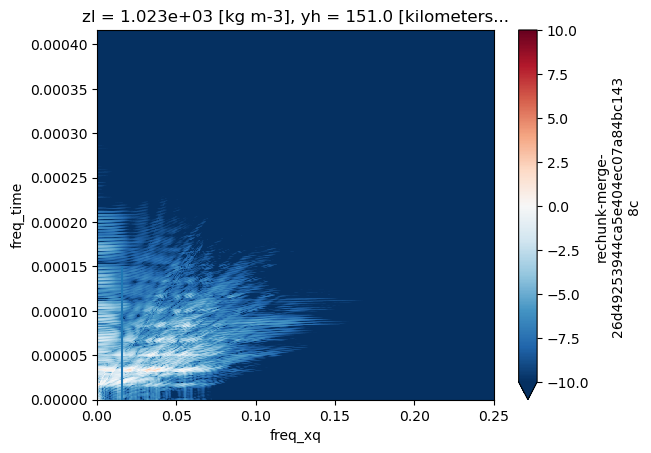

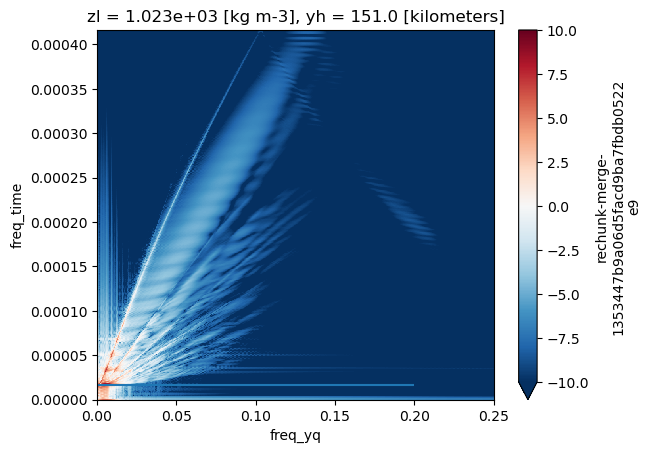

In [37]:
f = 0.0001 / (np.pi * 2)
w = 0.1 / (np.pi * 2)


zonal_PS = xrft.power_spectrum(u_zon.chunk({"xq":-1,"time":-1}),dim = ["time","xq"])
zonal_PS += xrft.power_spectrum(v_zon.chunk({"xq":-1,"time":-1}),dim = ["time","xq"])
# meridional_PS = xrft.power_spectrum(u_merid.chunk({"yq":-1,"time":-1}),dim = ["time","yq"])
meridional_PS = xrft.power_spectrum(v_merid.chunk({"yq":-1,"time":-1}),dim = ["time","yq"])
meridional_PS += xrft.power_spectrum(u_merid.chunk({"yq":-1,"time":-1}),dim = ["time","yq"])
np.log(zonal_PS.isel(zl = 4)).plot(vmin = -10)
plt.xlim(0,None)
plt.ylim(0,None)
plt.vlines(w,0,0.00015)

plt.hlines(f,0,None)
plt.figure()
np.log(meridional_PS.isel(zl = 4)).plot(vmin = -10)
plt.xlim(0,None)
plt.ylim(0,None)
plt.hlines(f,0,0.2)
print(zonal_PS.where(np.abs(zonal_PS.freq_time) > f,0).mean("zl").mean("freq_time").integrate("freq_xq").values)
print(meridional_PS.where(np.abs(meridional_PS.freq_time) > f,0).mean("zl").mean("freq_time").integrate("freq_yq").values)

## Remove +-100km from meridional

/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/distributed/client.py:3357: UserWarning: Sending large graph of size 159.70 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(
/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/distributed/client.py:3357: UserWarning: Sending large graph of size 159.70 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(


Text(0.5, 1.0, 'Meridional waves, $\\pm$ 100km removed, allth layer (time-averaged)')

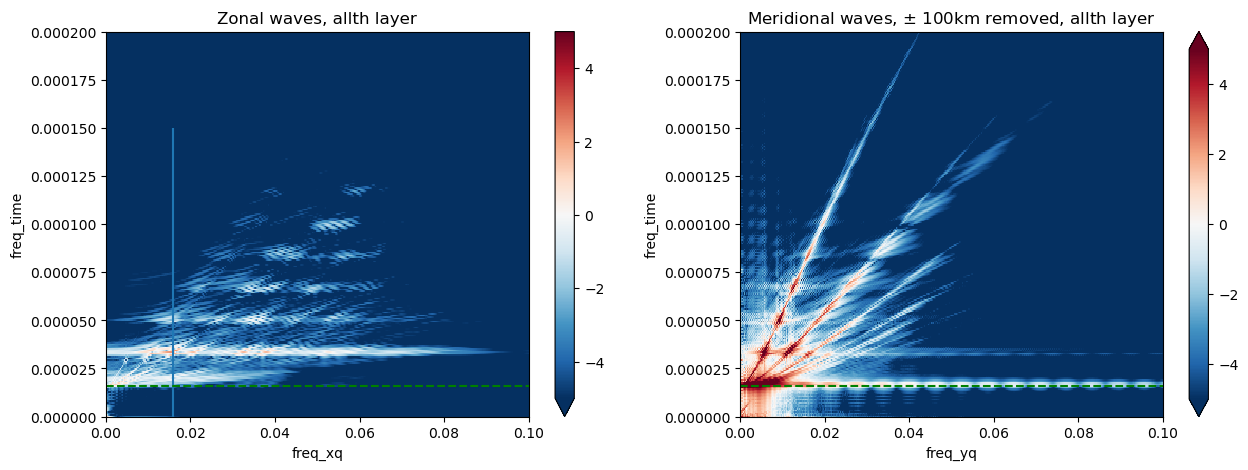

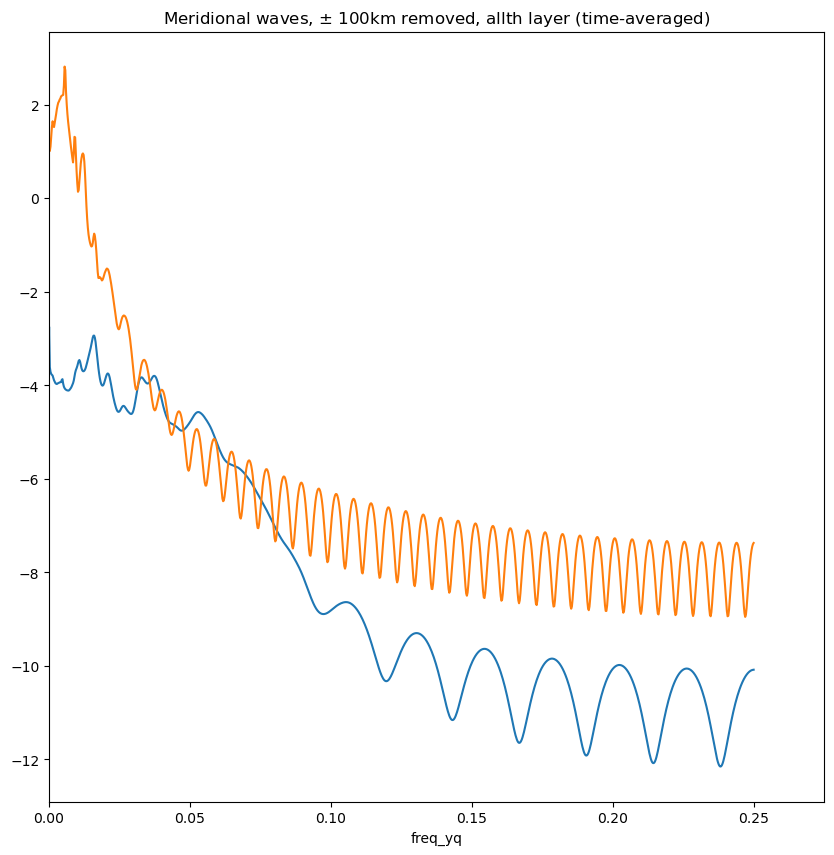

In [31]:
f = 0.0001 / (np.pi * 2)
w = 0.1 / (np.pi * 2)

z = slice(1,None)

zonal_restricted = u_zon.where(np.abs(u_zon.xq) > 20,0).isel(zl = z).load()
merid_restricted = v_merid.where(np.abs(v_merid.yq) > 80,0).isel(zl = z).load()

if type(z) == slice:
    z = "all"

zonal_PS = xrft.power_spectrum(zonal_restricted, dim=["time", "xq"])
meridional_PS = xrft.power_spectrum(merid_restricted, dim=["time", "yq"])

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

np.log(zonal_PS.mean("zl")).plot(vmin=-5, ax=axes[0])
axes[0].set_xlim(0, 0.1)
axes[0].set_ylim(0, 0.0002)
axes[0].vlines(w, 0, 0.00015)
axes[0].set_title(f"Zonal waves, {z}th layer")
axes[0].hlines(f, 0, 0.25,color = "green",linestyle = "--")

np.log(meridional_PS.mean("zl")).plot(vmin=-5, ax=axes[1])
axes[1].set_xlim(0, 0.1)
axes[1].set_ylim(0, 0.0002)
axes[1].hlines(f, 0, 0.25,color = "green",linestyle = "--")
axes[1].set_title(fr"Meridional waves, $\pm$ 100km removed, {z}th layer")

fig1, axes1 = plt.subplots(nrows=1, ncols=1, figsize=(10, 10))

np.log(zonal_PS.mean("zl").mean("freq_time")).plot( ax=axes1)
np.log(meridional_PS.mean("zl").mean("freq_time")).plot( ax=axes1)
axes1.set_xlim(0, None)
axes1.set_title(fr"Meridional waves, $\pm$ 100km removed, {z}th layer (time-averaged)")

## Restrict spatial domain by deleting, not infilling with 0s

In [32]:
x_cutoff = 10
y_cutoff = 100
x_cutoff //= 2
y_cutoff //= 2

zonal_restricted = u_zon.copy(deep=True)
merid_restricted = v_merid.copy(deep=True)

zonal_restricted[:,:,1000:2000 - x_cutoff:] = zonal_restricted[:,:,1000 + x_cutoff:2000].values
zonal_restricted[:,:,x_cutoff:1000] = zonal_restricted[:,:,0:1000 - x_cutoff].values
merid_restricted[:,:,1000:2000 - y_cutoff:] = merid_restricted[:,:,1000 + y_cutoff:2000].values
merid_restricted[:,:,y_cutoff:1000] = merid_restricted[:,:,0:1000 - y_cutoff].values


# if type(z) == slice:
#     z = "all"

zonal_PS = xrft.power_spectrum(zonal_restricted.load(), dim=["time", "xq"])
meridional_PS = xrft.power_spectrum(merid_restricted.load(), dim=["time", "yq"])

/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/distributed/client.py:3357: UserWarning: Sending large graph of size 167.68 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(
/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/distributed/client.py:3357: UserWarning: Sending large graph of size 334.44 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(
/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/distributed/client.py:3357: UserWarning: Sending large graph of size 326.90 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(
/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/distributed/client.py:3357: UserWarning: Sending large graph of size 501.19 MiB.
This may cause some s

In [48]:
u_zon.time.values[1] - u_zon.time.values[0]

1200.0

## NICE SPECTRA PLOT


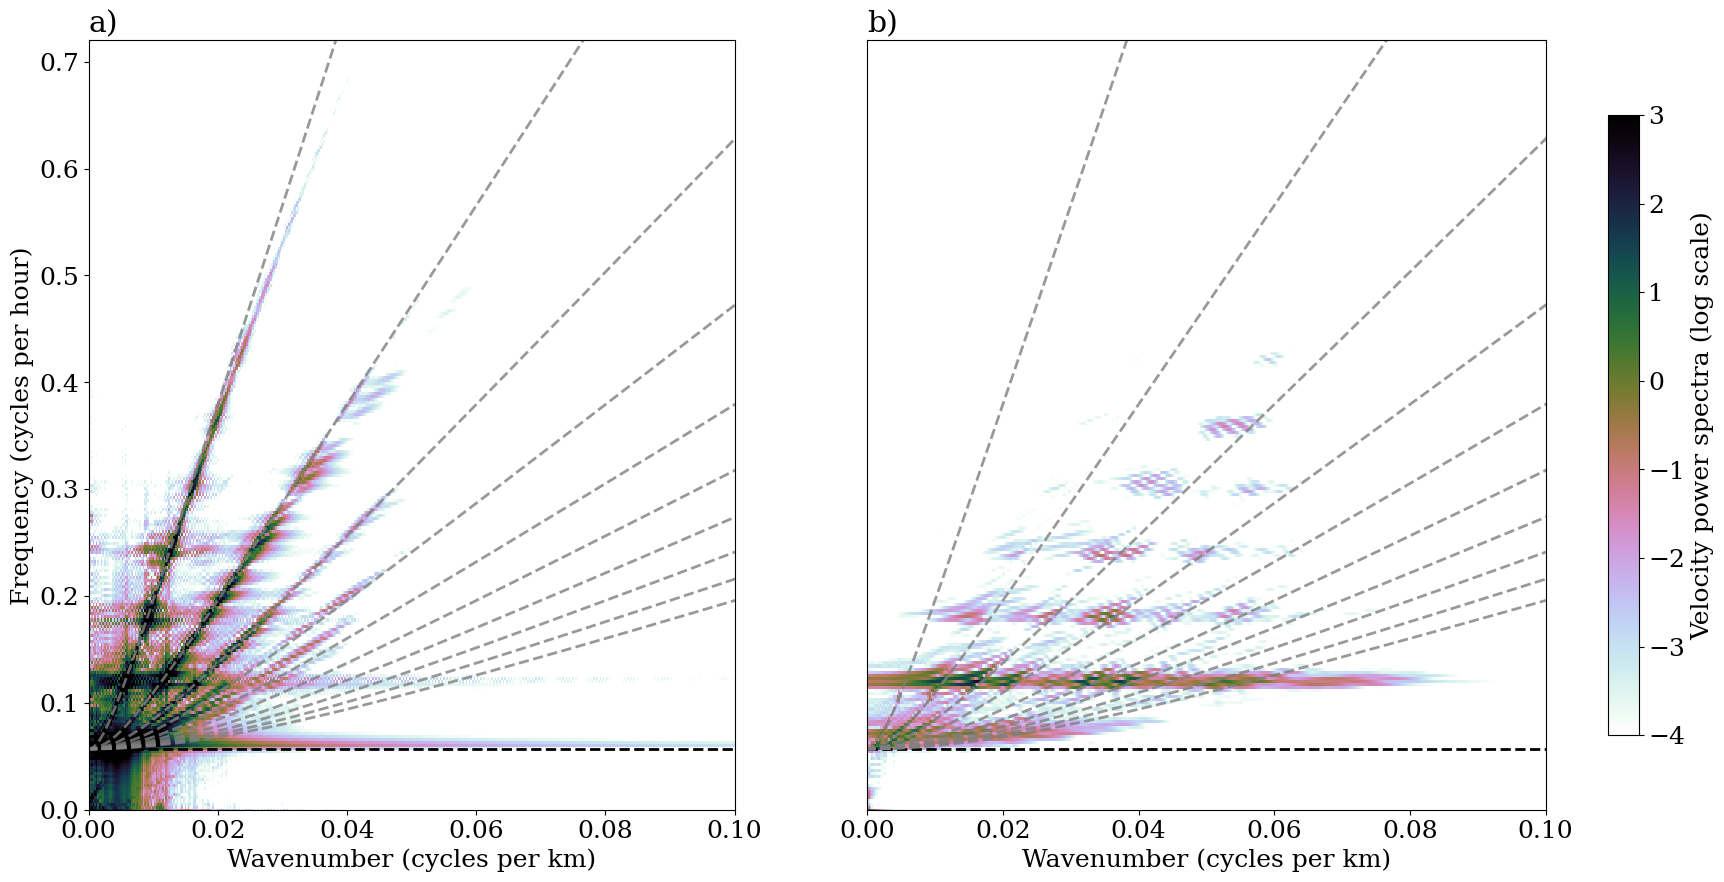

In [78]:
font = {'family' : 'serif',
        'weight':'normal',
        'size'   : 18}
import matplotlib

matplotlib.rc('font', **font)
cmap = "magma"
framedim = "time"
import seaborn as sns
cmap = sns.color_palette("cubehelix_r", as_cmap=True)

f = 0.0001 / (np.pi * 2)
w = 1 / 20
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 10), gridspec_kw={'width_ratios': [1, 1.05]})

im0 = np.log(zonal_PS.assign_coords({"freq_time": zonal_PS.freq_time * 3600}).isel(zl = slice(1,None)).mean("zl")).plot(vmax = 3,vmin=-4, ax=axes[1], add_colorbar=False, cmap=cmap)
axes[1].set_xlim(0, 0.1)
axes[1].set_ylim(0, 0.0002 * 3600)
# axes[1].vlines(w, 0,0.7, color="red", linestyle="--",linewidth = 2)
axes[1].hlines(f * 3600, 0, 0.25, color="black", linestyle="--",linewidth = 2)

im1 = np.log(meridional_PS.assign_coords({"freq_time": zonal_PS.freq_time * 3600}).isel(zl = slice(1,None)).mean("zl")).plot(vmax = 3,vmin=-4, ax=axes[0], cmap=cmap,add_colorbar=False)
axes[0].set_xlim(0, 0.1)
axes[1].set_yticks([])
axes[1].set_ylabel("")
axes[0].set_ylim(0, 0.0002 * 3600)
axes[0].hlines(f * 3600, 0, 0.25, color="black", linestyle="--",linewidth = 2)


#! Add vertical modes
def vmodes(k,n):
    # k /= 1000 # convert to m^-1
    H = 4000
    f = 0.0001 / (np.pi * 2) # f in s^-1
    N = 40 * f  # N in s^-1
    N = np.sqrt((9.8 * 0.35) / (200 * 1025)) 
    # N = np.sqrt((2 * 9.8) / (4000 * 1027))  # N in s^-1
    m = np.pi * n / H
    K2 = k**2
    num = f**2 * m**2 + K2 * N ** 2
    den = m ** 2
    return np.sqrt(num / den) * 3600 # convert back to cycles per hour


for i in range(1,11):
    axes[0].plot(zonal_PS.freq_xq.values,vmodes(zonal_PS.freq_xq.values * 1e-3,i),color = "grey",lw = 2,linestyle = "--",alpha = 0.8)
    axes[1].plot(zonal_PS.freq_xq.values,vmodes(zonal_PS.freq_xq.values * 1e-3,i),color = "grey",lw = 2,linestyle = "--",alpha = 0.8)

#!

axes[0].set_title("")
axes[1].set_title("")
axes[0].set_title("a)",loc = "left")
axes[1].set_title("b)",loc = "left")
axes[0].set_ylabel("Frequency (cycles per hour)")
axes[0].set_xlabel("Wavenumber (cycles per km)")
axes[1].set_xlabel("Wavenumber (cycles per km)")
# Add shared colorbar
cbar = fig.colorbar(im1, ax=axes, orientation='vertical', fraction=0.02, pad=0.04)
cbar.set_label('Velocity power spectra (log scale)')

In [59]:
N = np.sqrt((9.8 * 0.35) / (200 * 1025))
print(N)
print(N/f)

0.004090440968535443
257.0099859338733


In [54]:
u_zon.zl

<xarray.DataArray 'zl' (zl: 21)> Size: 168B
array([1018.675, 1021.675, 1022.025, 1022.375, 1022.725, 1023.075, 1023.425,
       1023.775, 1024.125, 1024.475, 1024.825, 1025.175, 1025.525, 1025.875,
       1026.225, 1026.575, 1026.925, 1027.275, 1027.625, 1027.975, 1028.325])
Coordinates:
  * zl       (zl) float64 168B 1.019e+03 1.022e+03 ... 1.028e+03 1.028e+03
    yh       float64 8B 151.0
Attributes:
    long_name:       Layer Target Potential Density
    units:           kg m-3
    cartesian_axis:  Z
    positive:        up

0.025
0.025
0.025
0.025
0.025
0.025


(0.0, 0.1)

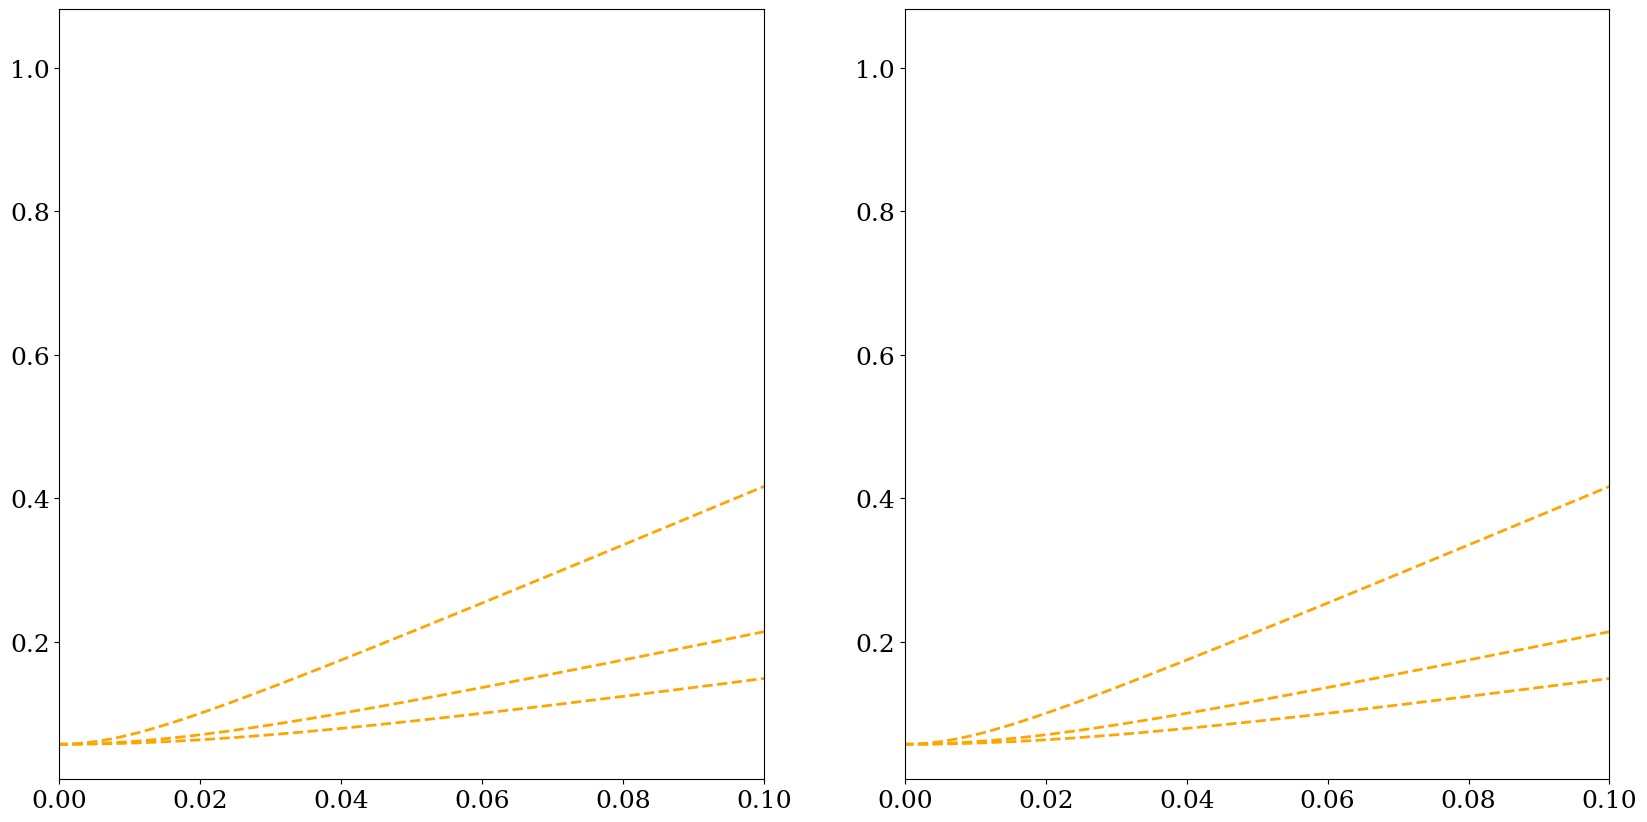

In [45]:
def vmodes(k,n):
    # k /= 1000 # convert to m^-1
    f = 0.0001 / (np.pi * 2) # f in s^-1
    N = 40 * f  # N in s^-1
    # N = np.sqrt((2 * 9.8) / (4000 * 1027))  # N in s^-1
    print(f / N)
    m = np.pi * n / 4000
    K2 = 2 * k**2
    num = f**2 * m**2 + K2 * N ** 2
    den = m ** 2
    return np.sqrt(num / den) * 3600 # convert back to cycles per hour

fig,axes = plt.subplots(1,2,figsize = (20,10))
for i in range(1,4):
    axes[0].plot(zonal_PS.freq_xq.values,vmodes(zonal_PS.freq_xq.values / 1000,i),color = "orange",lw = 2,linestyle = "--",alpha = 1)
    axes[1].plot(zonal_PS.freq_xq.values,vmodes(zonal_PS.freq_xq.values / 1000,i),color = "orange",lw = 2,linestyle = "--",alpha = 1)

axes[0].set_xlim(0, 0.1)
axes[1].set_xlim(0, 0.1)


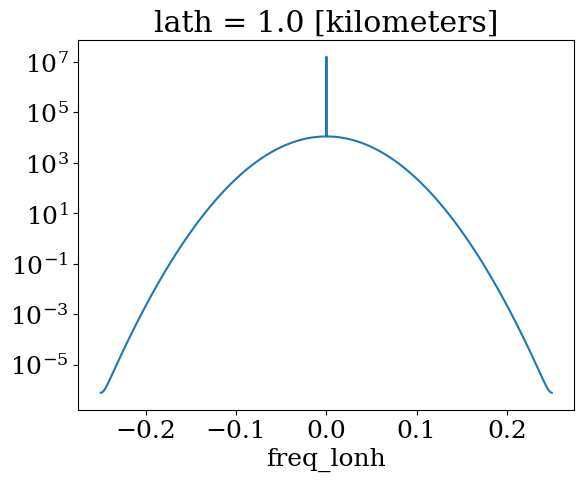

In [77]:
topo = xr.open_dataset("/scratch/nm03/ab8992/mom6/archive/default/output000/ocean_geometry.nc").D.sel(lath = 0,method = "nearest")
# topo -= topo.mean("lonh")
np.abs(xrft.fft(topo,dim = "lonh")).plot()
# plt.xlim(0,0.1)
plt.yscale("log")

## 2D spectra

/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/distributed/client.py:3357: UserWarning: Sending large graph of size 130.89 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(
/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/distributed/client.py:3357: UserWarning: Sending large graph of size 130.89 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(


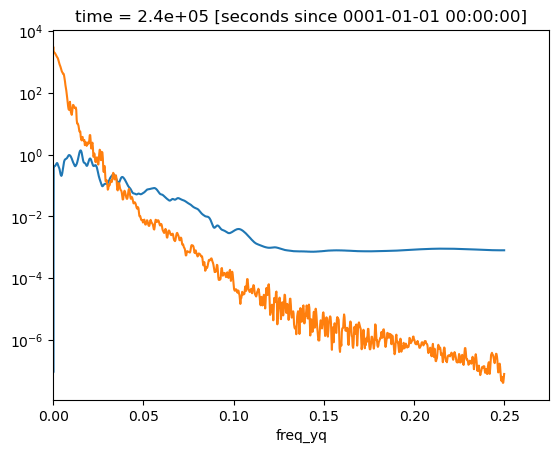

In [ ]:
# f = 0.0001 / (np.pi * 2)
# w = 0.1 / (np.pi * 2)
zonal_hor_spectra = np.abs(xrft.fft(u_zon.chunk({"xq":-1,"time":-1}),dim = ["xq"])**2)
zonal_hor_spectra+= np.abs(xrft.fft(v_zon.chunk({"xq":-1,"time":-1}),dim = ["xq"])**2)
merid_hor_spectra = np.abs(xrft.fft(u_merid.chunk({"yq":-1,"time":-1}),dim = ["yq"])**2)
merid_hor_spectra+= np.abs(xrft.fft(v_merid.chunk({"yq":-1,"time":-1}),dim = ["yq"])**2)

# zonal_hor_spectra /= zonal_hor_spectra.mean("time")
# merid_hor_spectra /= merid_hor_spectra.mean("time")

zonal_hor_spectra.mean("zl").isel(time = slice(100,None)).isel(time = -5).plot()
merid_hor_spectra.mean("zl").isel(time = slice(100,None)).isel(time = -5).plot()

plt.xlim(0,None)
plt.yscale("log")
# plt.xscale("log")

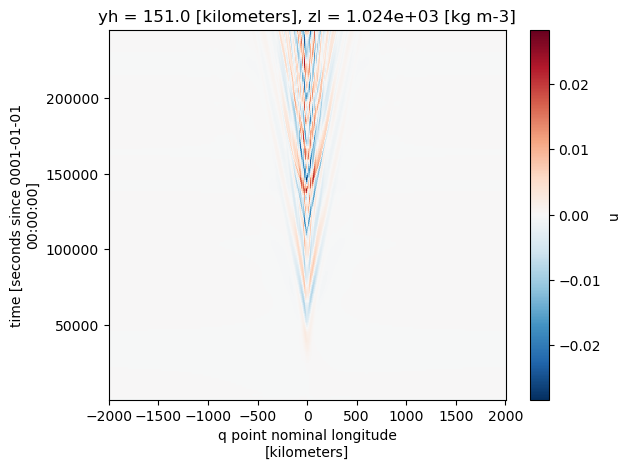

In [22]:
u_zon.isel(zl = 9).plot()


In [28]:
v_merid.isel(time = -5,zl = 2).mean("yq").values


array(5.03886622e-05)

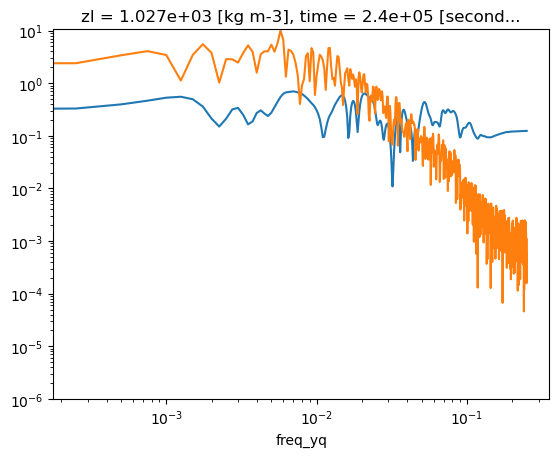

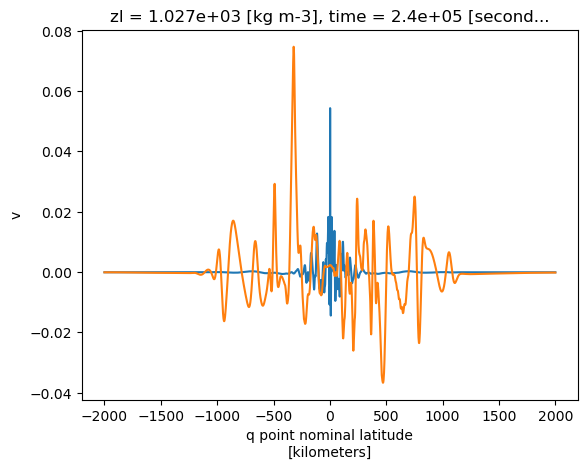

In [43]:
np.abs(xrft.fft(u_zon.isel(time = -5),dim = "xq")).isel(zl = -5).plot()
np.abs(xrft.fft(v_merid.isel(time = -5),dim = "yq")).isel(zl = -5).plot()
# u_zon.isel(time = -5,zl = 2).plot()
plt.ylim(1e-6,None)
plt.yscale("log")
plt.xscale("log")
plt.figure()
u_zon.isel(time = -5).isel(zl = -5).plot()
v_merid.isel(time = -5).isel(zl = -5).plot()

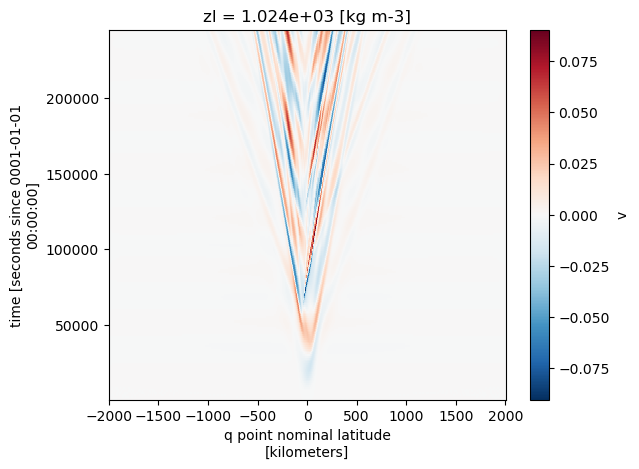

In [24]:
v_merid.isel(zl = 9).plot()

## 2D spectra, remove superinertial

/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/distributed/client.py:3357: UserWarning: Sending large graph of size 130.86 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(
/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/distributed/client.py:3357: UserWarning: Sending large graph of size 130.86 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(


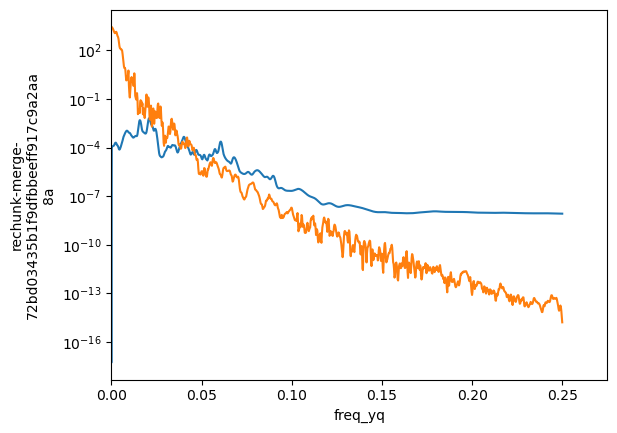

In [6]:
f = 0.0001 / (np.pi * 2)
# w = 0.1 / (np.pi * 2)
zonal_hor_spectra = np.abs(xrft.power_spectrum(u_zon.isel(time = slice(100,None))
.isel(time = slice(100,None)).chunk({"xq":-1,"time":-1}),dim = ["xq","time"])**2)
zonal_hor_spectra+= np.abs(xrft.power_spectrum(v_zon.isel(time = slice(100,None))
.isel(time = slice(100,None)).chunk({"xq":-1,"time":-1}),dim = ["xq","time"])**2)
merid_hor_spectra = np.abs(xrft.power_spectrum(u_merid.isel(time = slice(100,None))
.isel(time = slice(100,None)).chunk({"yq":-1,"time":-1}),dim = ["yq","time"])**2)
merid_hor_spectra+= np.abs(xrft.power_spectrum(v_merid.isel(time = slice(100,None))
.isel(time = slice(100,None)).chunk({"yq":-1,"time":-1}),dim = ["yq","time"])**2)

merid_hor_spectra = merid_hor_spectra.where(np.abs(merid_hor_spectra.freq_time) > f)
zonal_hor_spectra = zonal_hor_spectra.where(np.abs(zonal_hor_spectra.freq_time) > f)

zonal_hor_spectra.mean("zl").mean("freq_time").plot()
merid_hor_spectra.mean("zl").mean("freq_time").plot()

plt.xlim(0,None)
plt.yscale("log")
# plt.xscale("log")

/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/distributed/client.py:3357: UserWarning: Sending large graph of size 65.42 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(


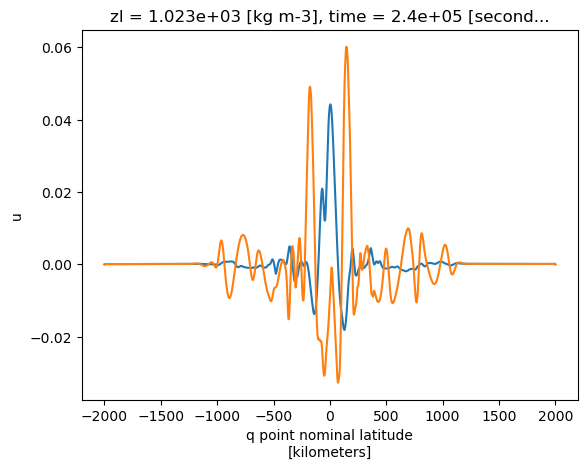

In [5]:
(u_merid).mean("zl").isel(time = slice(100,None)).isel(time = -5).plot()
(u_merid).isel(zl = 5).isel(time = slice(100,None)).isel(time = -5).plot()



In [13]:
u_zcoord = u_zon.isel(zl = slice(1,None)).assign_coords({"zl":np.linspace(0,4000,20)})
u_zspectra = xrft.fft(u_zcoord.isel(time = -10).load(),dim = ["zl","xq"])
v_zcoord = v_merid.isel(zl = slice(1,None)).assign_coords({"zl":np.linspace(0,4000,20)})
v_zspectra = xrft.fft(v_zcoord.isel(time = -10).load(),dim = ["zl","yq"])

/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/distributed/client.py:3357: UserWarning: Sending large graph of size 62.29 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(
/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/distributed/client.py:3357: UserWarning: Sending large graph of size 62.29 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(


(0.0, 0.00225625)

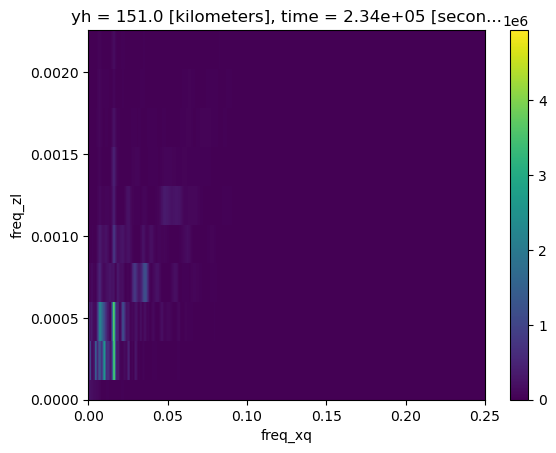

In [12]:
np.abs(u_zspectra**2).plot()
plt.xlim(0,None)
plt.ylim(0,None)

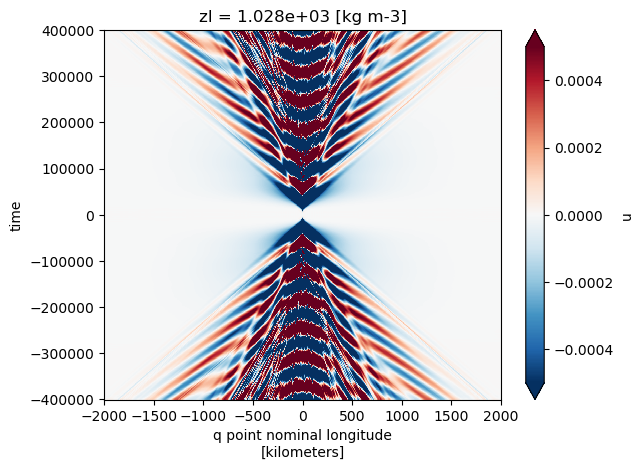

In [14]:
u_zon.isel(zl = slice(1,None)).isel(zl = -2).plot(vmin = -0.0005,vmax = 0.0005,cmap = "RdBu_r")


(0.0, 300000.0)

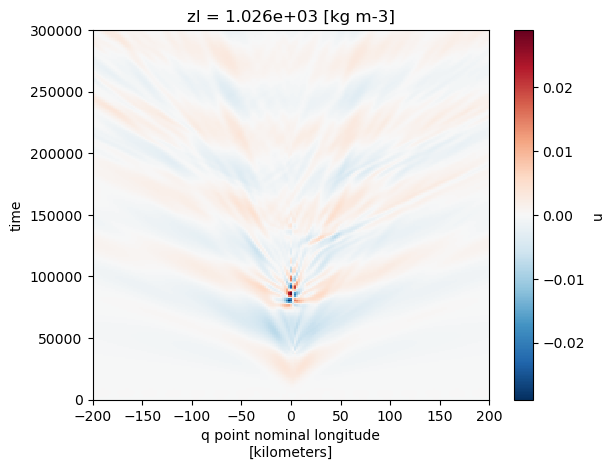

In [37]:
u_zon.isel(zl = 13).plot()
plt.xlim(-200,200)
plt.ylim(0,300000)

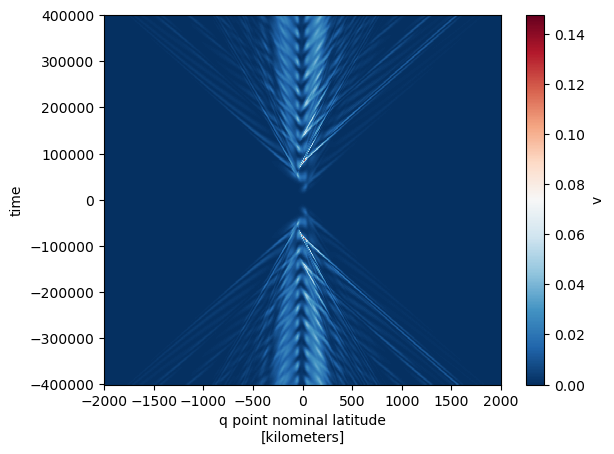

In [19]:
(v_merid**2).isel(zl = slice(1,None)).sum("zl").plot(cmap = "RdBu_r")


/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/distributed/client.py:3357: UserWarning: Sending large graph of size 201.98 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(


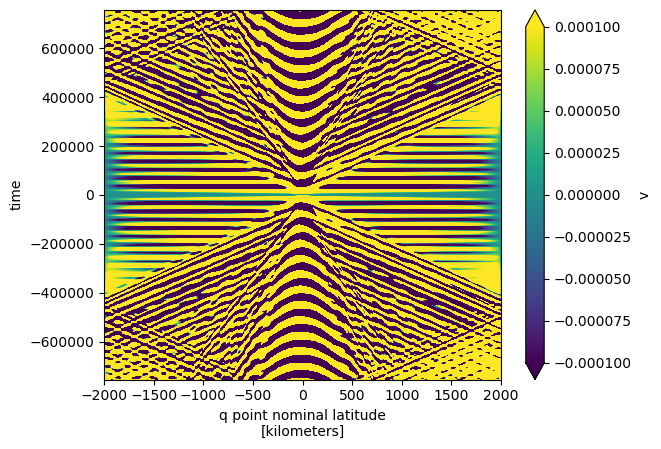

In [21]:
v_merid.mean("zl").plot(vmin = -0.0001,vmax = 0.0001)

(0.0, 0.00015)

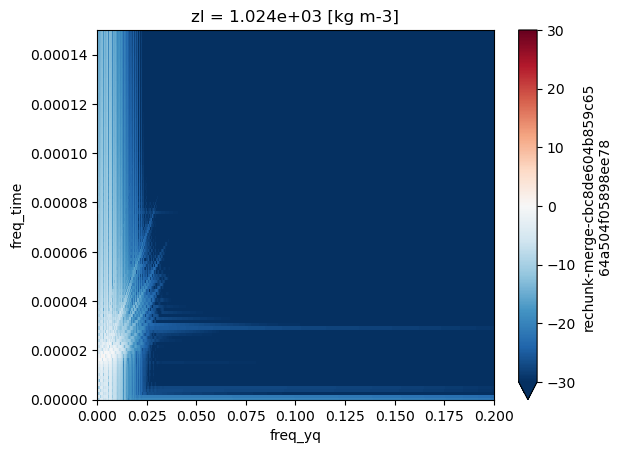

In [154]:
np.log(xrft.power_spectrum(u_merid.chunk({"time":-1}),dim = ["time","yq"]).isel(zl = 9)).plot(vmin = -30)
plt.xlim(0,0.2)
plt.ylim(0,0.00015)

## Flip the data as before to remove ringing:

(0.0, 0.1)

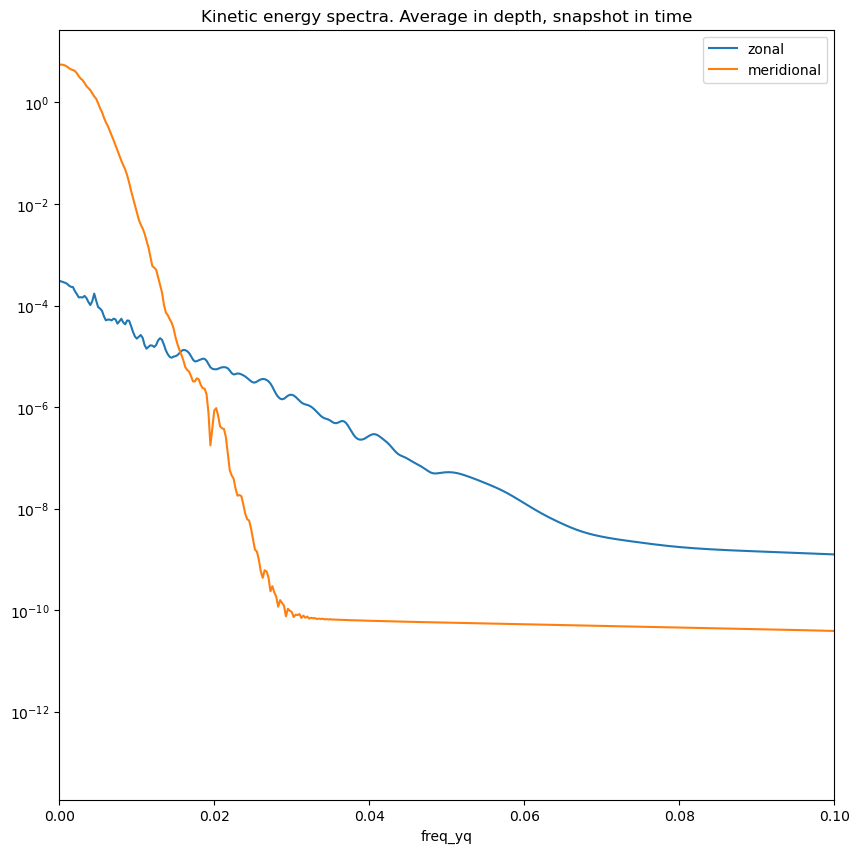

In [110]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(10, 10))

zon_KE = np.real(np.abs(xrft.fft(u_zon, dim="xq"))**2 + np.abs(xrft.fft(v_zon, dim="xq"))**2)
merid_KE = np.real(np.abs(xrft.fft(u_merid, dim="yq"))**2 + np.abs(xrft.fft(v_merid, dim="yq"))**2)
# v_FFT = xrft.fft(v_doubled, dim="yq")

zon_KE.isel(time = slice(None,None)).mean("zl").isel(time = -50).plot(ax = axes,label = "zonal")
merid_KE.isel(time = slice(None,None)).mean("zl").isel(time = -50).plot(ax = axes,label = "meridional")
# np.abs(v_FFT.isel(time = slice(100,None))).mean("time").mean("zl").plot(ax = axes,label = "meridional")


axes.set_title('Kinetic energy spectra. Average in depth, snapshot in time')
# axes.set_xscale('log')
axes.set_yscale('log')
axes.legend()
axes.set_xlim(0,0.1)


In [109]:
1/20

0.05

In [107]:
print((zon_KE.mean("zl").isel(time = -50).mean("freq_xq").values))
print(merid_KE.mean("zl").isel(time = -50).mean("freq_yq").values)

5.531509133319286e-06
0.07202725628047608


(0.0, 0.1)

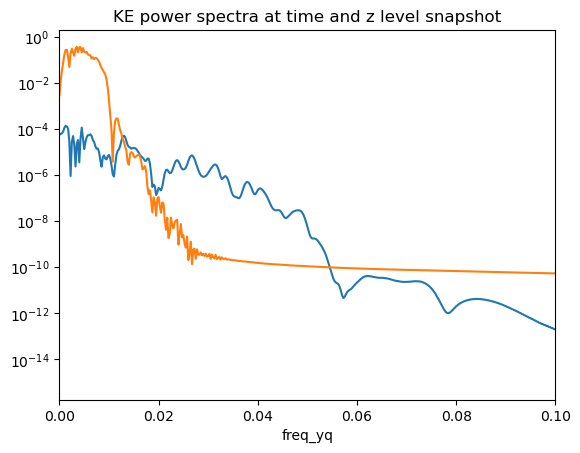

In [84]:
zon_KE.isel(time = -5,zl = 5).plot(label = "zonal")
merid_KE.isel(time = -5,zl = 5).plot(label = "merid")
# plt.xscale('log')
plt.yscale('log')
plt.title("KE power spectra at time and z level snapshot")
plt.xlim(0,0.1)

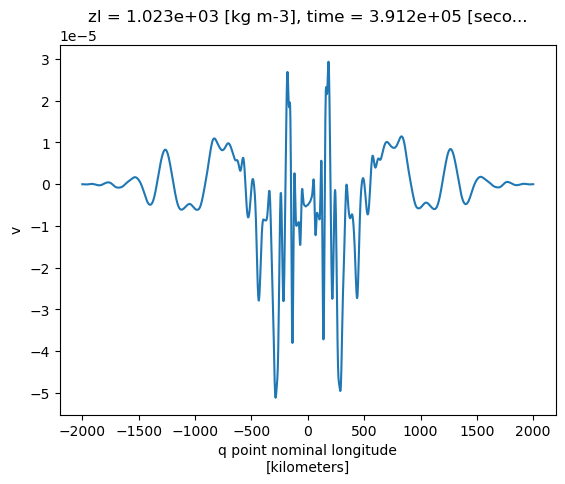

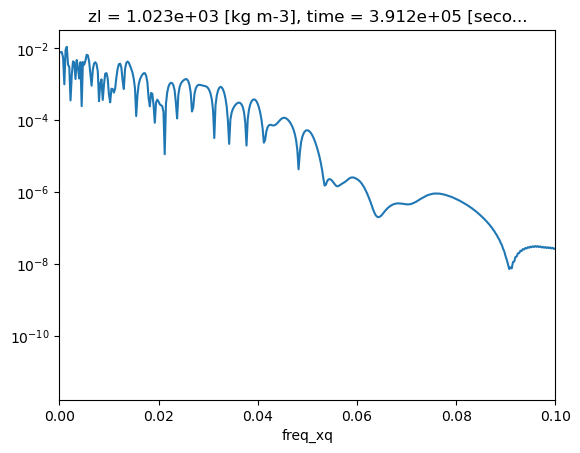

In [88]:
v_zon.isel(time = -5,zl = 5).plot()
plt.figure()
np.abs(xrft.fft(v_zon.isel(time = -5,zl = 5), dim="xq")).plot()
plt.xlim(0,0.1)
plt.yscale('log')

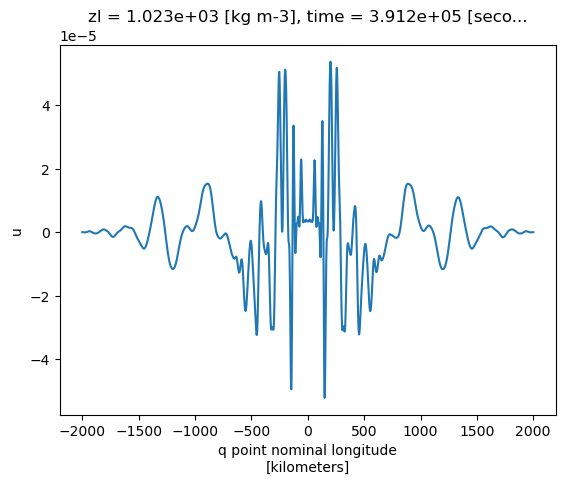

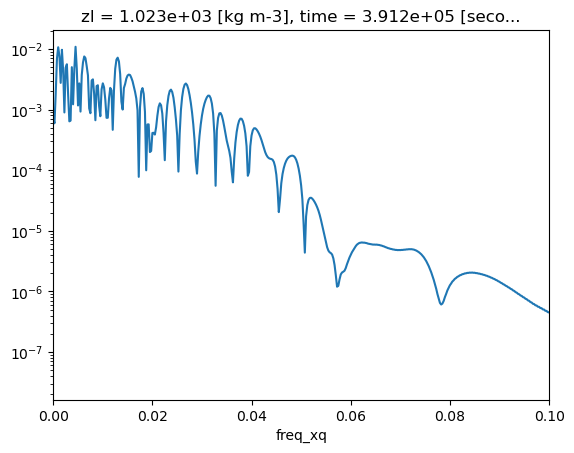

In [87]:
u_zon.isel(time = -5,zl = 5).plot()
plt.figure()
np.abs(xrft.fft(u_zon.isel(time = -5,zl = 5), dim="xq")).plot()
plt.xlim(0,0.1)
plt.yscale('log')

Text(0.5, 0, 'log wavenumber (1/km)')

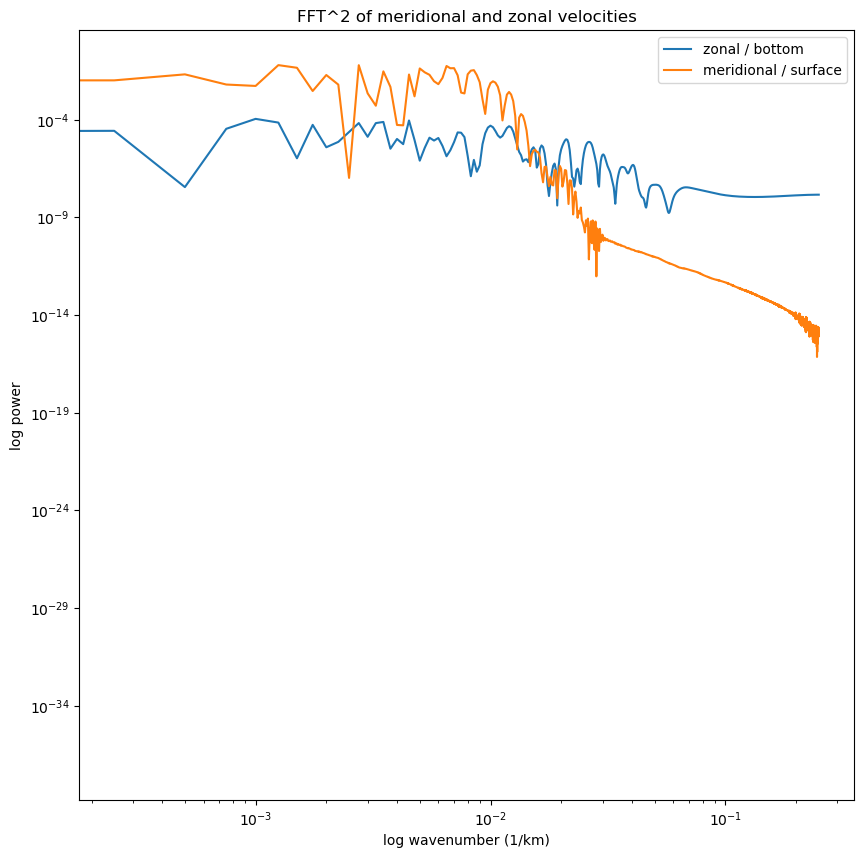

In [11]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(10, 10))

np.abs(xrft.fft(u_doubled.isel(time = -5), dim="xq")**2).isel(zl = -5).sel(freq_xq=slice(0, None)).plot(ax=axes,label = "zonal / bottom")
axes.set_title('FFT of u')
# axes[0].vlines(1/ (10),0,12)
np.abs(xrft.fft(v_doubled.isel(time = -5), dim="yq")**2).isel(zl = -5).sel(freq_yq=slice(0, None)).plot(ax=axes,label = "meridional / surface")
axes.set_title('FFT^2 of meridional and zonal velocities')
axes.set_xscale('log')
axes.set_yscale('log')

axes.legend()

axes.set_ylabel("log power")
axes.set_xlabel("log wavenumber (1/km)")

/jobfs/136174160.gadi-pbs/ipykernel_1897913/2212131487.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes.legend()


Text(0.5, 0, 'log wavenumber (1/km)')

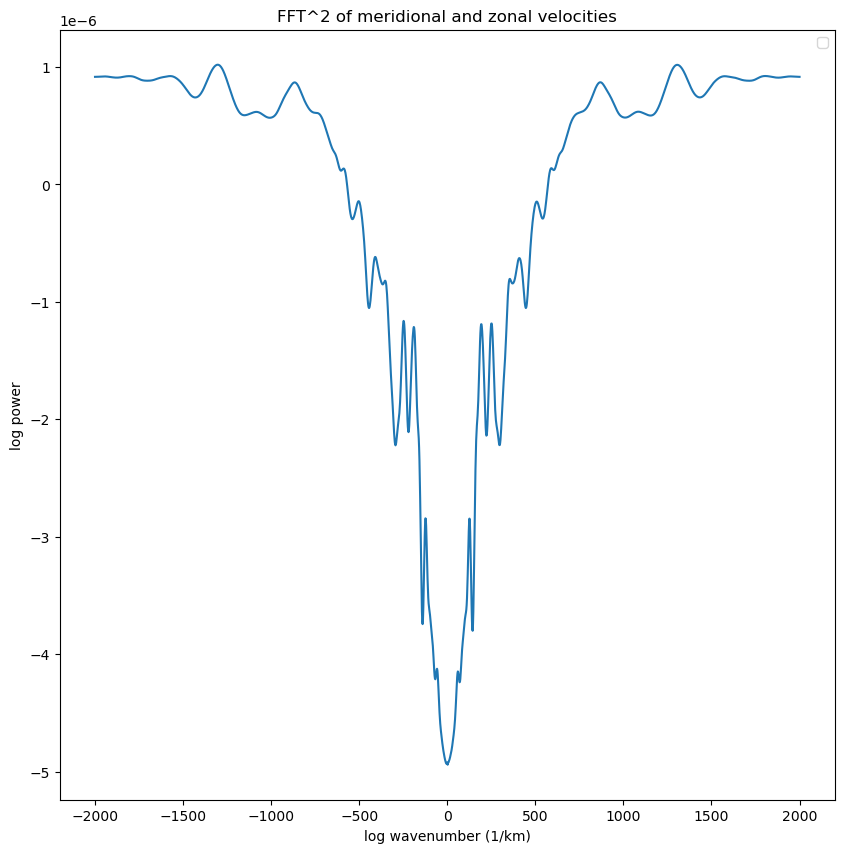

In [12]:
# plt.xlim(0,None)
# plt.xscale("log")

fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(10, 10))

# u_doubled.isel(zl = 5).isel(time = -5).plot(ax = axes)
u_doubled.isel(zl = 5).mean("time").plot(ax = axes)

axes.set_title('FFT^2 of meridional and zonal velocities')
# axes.set_xscale('log')
# axes.set_yscale('log')

axes.legend()

axes.set_ylabel("log power")
axes.set_xlabel("log wavenumber (1/km)")

In [9]:
u_doubled.isel(zl = 5).isel(time = -5).mean("xq").values

array(-2.77687963e-22)

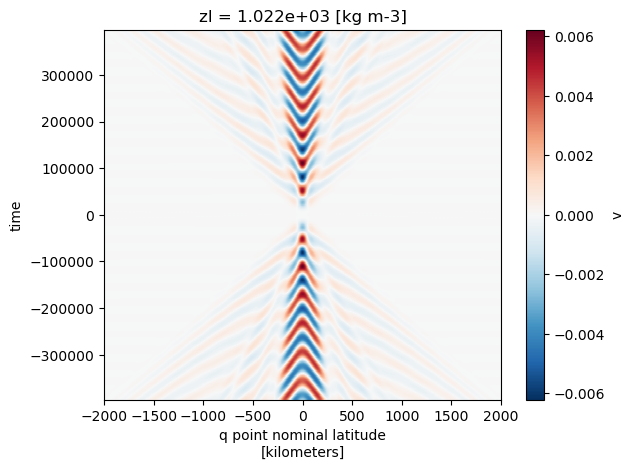

In [91]:
v_doubled.sel(yq = slice(-2000,2000)).isel(zl = 2).plot()
